In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from collections import Counter

In [2]:
dataset_path = Path(r"D:\AI_Diploma\Training tasks\Sprint_2\dataset")

print(dataset_path)

D:\AI_Diploma\Training tasks\Sprint_2\dataset


In [3]:
print("Dataset exists:", dataset_path.exists())

Dataset exists: True


In [4]:
top_level_items = list(dataset_path.iterdir())

for item in sorted(top_level_items):
    if item.is_dir():
        print(f"[DIR]  {item.name}")
    else:
        print(f"[FILE] {item.name}")

[DIR]  Calculus
[DIR]  Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
[DIR]  Data caries
[DIR]  Gingivitis
[DIR]  hypodontia
[DIR]  Mouth Ulcer
[DIR]  Tooth Discoloration


In [5]:
for folder in sorted(dataset_path.iterdir()):
    if folder.is_dir():
        print(f"\n{'=' * 60}")
        print(folder.name)
        print(f"{'=' * 60}")

        for item in sorted(folder.iterdir())[:10]:
            print("  ", item.name)


Calculus
   Calculus

Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
   Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset

Data caries
   Data caries

Gingivitis
   Gingivitis

hypodontia
   hypodontia

Mouth Ulcer
   Mouth Ulcer

Tooth Discoloration
   Tooth Discoloration


In [6]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = [
    file
    for file in dataset_path.rglob("*")
    if file.is_file() and file.suffix.lower() in image_extensions
]

print("Total images found:", len(image_files))

Total images found: 13862


In [7]:
image_records = []

for image_path in image_files:
    relative_path = image_path.relative_to(dataset_path)

    image_records.append({
        "file_name": image_path.name,
        "extension": image_path.suffix.lower(),
        "relative_path": str(relative_path),
        "top_level_folder": relative_path.parts[0],
    })

images_df = pd.DataFrame(image_records)

images_df.head()

,file_name,extension,relative_path,top_level_folder
0,Tooth_Discoloration_0_1.jpeg,.jpeg,Tooth Discoloration\Tooth Discoloration\Tooth_...,Tooth Discoloration
1,Tooth_Discoloration_0_1001.jpeg,.jpeg,Tooth Discoloration\Tooth Discoloration\Tooth_...,Tooth Discoloration
2,Tooth_Discoloration_0_1002.jpeg,.jpeg,Tooth Discoloration\Tooth Discoloration\Tooth_...,Tooth Discoloration
3,Tooth_Discoloration_0_1007.jpeg,.jpeg,Tooth Discoloration\Tooth Discoloration\Tooth_...,Tooth Discoloration
4,Tooth_Discoloration_0_1008.jpeg,.jpeg,Tooth Discoloration\Tooth Discoloration\Tooth_...,Tooth Discoloration


top_level_folder
Calculus                                                             1296
Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset    1542
Data caries                                                          2601
Gingivitis                                                           2349
Mouth Ulcer                                                          2806
Tooth Discoloration                                                  2017
hypodontia                                                           1251
Name: count, dtype: int64


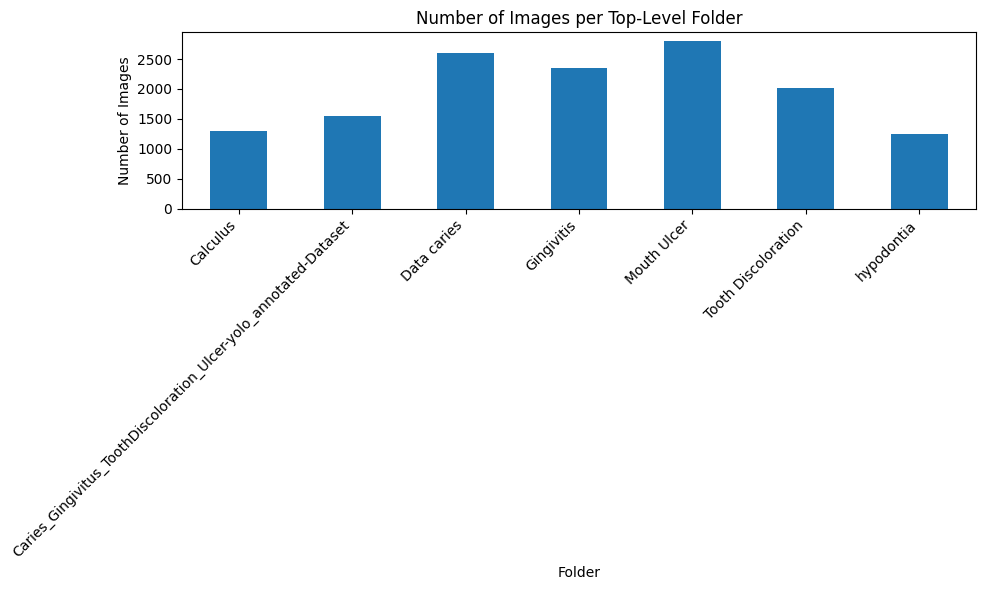

In [8]:
images_per_folder = (
    images_df["top_level_folder"]
    .value_counts()
    .sort_index()
)

print(images_per_folder)


plt.figure(figsize=(10, 6))

images_per_folder.plot(kind="bar")

plt.title("Number of Images per Top-Level Folder")
plt.xlabel("Folder")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
YOLO_FOLDER = "Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset"

classification_images_df = images_df[
    images_df["top_level_folder"] != YOLO_FOLDER
].copy()

print(
    "Classification images:",
    len(classification_images_df)
)

print(
    "YOLO images:",
    len(images_df) - len(classification_images_df)
)



classification_images_df["top_level_folder"].value_counts()

Classification images: 12320
YOLO images: 1542


top_level_folder
Mouth Ulcer            2806
Data caries            2601
Gingivitis             2349
Tooth Discoloration    2017
Calculus               1296
hypodontia             1251
Name: count, dtype: int64

In [11]:
classification_images_df["extension"].value_counts()


extension
.jpeg    6757
.jpg     5563
Name: count, dtype: int64

In [12]:
dimensions = []

for image_path in image_files:
    if YOLO_FOLDER in image_path.parts:
        continue

    try:
        with Image.open(image_path) as img:
            dimensions.append({
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format,
                "path": str(image_path)
            })

    except Exception as e:
        print("Could not read:", image_path)

In [14]:
dimensions_df = pd.DataFrame(dimensions)

dimensions_df.head()

dimensions_df[["width", "height"]].describe()

,width,height
count,12320.000000,12320.000000
mean,422.970942,278.397321
std,173.194843,126.447382
min,121.000000,33.000000
25%,274.000000,180.000000
50%,332.000000,221.500000
75%,612.000000,408.000000
max,685.000000,612.000000


In [15]:
dimension_counts = (
    dimensions_df
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
)

dimension_counts.head(20)

width  height
612    408       2942
275    183        820
259    194        331
300    168        296
612    407        280
       406        194
       405        167
225    225        162
276    183        149
612    459         98
408    612         94
194    259         84
274    184         79
268    188         79
612    372         77
       317         72
       409         71
       293         66
283    178         65
284    177         64
dtype: int64

In [16]:
corrupted_images = []

for image_path in image_files:

    if YOLO_FOLDER in image_path.parts:
        continue

    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:
        corrupted_images.append(str(image_path))

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


In [17]:
class_mapping = {
    "Data caries": "Caries"
}

In [18]:
image_modes = []

for image_path in image_files:

    if YOLO_FOLDER in image_path.parts:
        continue

    try:
        with Image.open(image_path) as img:
            image_modes.append(img.mode)

    except Exception:
        pass

Counter(image_modes)

Counter({'RGB': 12288, 'RGBA': 32})

In [19]:
import hashlib

def get_image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
    
hash_records = []

for image_path in image_files:

    if YOLO_FOLDER in image_path.parts:
        continue

    try:
        image_hash = get_image_hash(image_path)

        hash_records.append({
            "path": str(image_path),
            "hash": image_hash
        })

    except Exception:
        pass

hash_df = pd.DataFrame(hash_records)


duplicate_hashes = (
    hash_df["hash"]
    .value_counts()
)

duplicate_hashes = duplicate_hashes[
    duplicate_hashes > 1
]

print("Number of duplicated image groups:", len(duplicate_hashes))


print(
    "Number of duplicate files:",
    duplicate_hashes.sum() - len(duplicate_hashes)
)

Number of duplicated image groups: 775
Number of duplicate files: 1664


In [20]:
# Add the class information to our hash dataframe
hash_df["class"] = hash_df["path"].apply(
    lambda x: Path(x).relative_to(dataset_path).parts[0]
)

# Find hashes that appear more than once

duplicate_hashes = hash_df[
    hash_df["hash"].duplicated(keep=False)
]

# For each duplicate hash, count how many different classes it appears in
duplicate_class_counts = (
    duplicate_hashes
    .groupby("hash")["class"]
    .nunique()
)

# Keep only duplicate groups that appear across different classes
cross_class_duplicates = duplicate_class_counts[
    duplicate_class_counts > 1
]

print("Duplicate groups across different classes:",
      len(cross_class_duplicates))

Duplicate groups across different classes: 392


In [21]:
# Get the hash of the first cross-class duplicate group
example_hash = cross_class_duplicates.index[0]

example_group = hash_df[
    hash_df["hash"] == example_hash
]

print(example_group[["class", "path"]].to_string(index=False))

     class                                                                           path
Gingivitis D:\AI_Diploma\Training tasks\Sprint_2\dataset\Gingivitis\Gingivitis\(2179).jpg
  Calculus     D:\AI_Diploma\Training tasks\Sprint_2\dataset\Calculus\Calculus\(1259).jpg


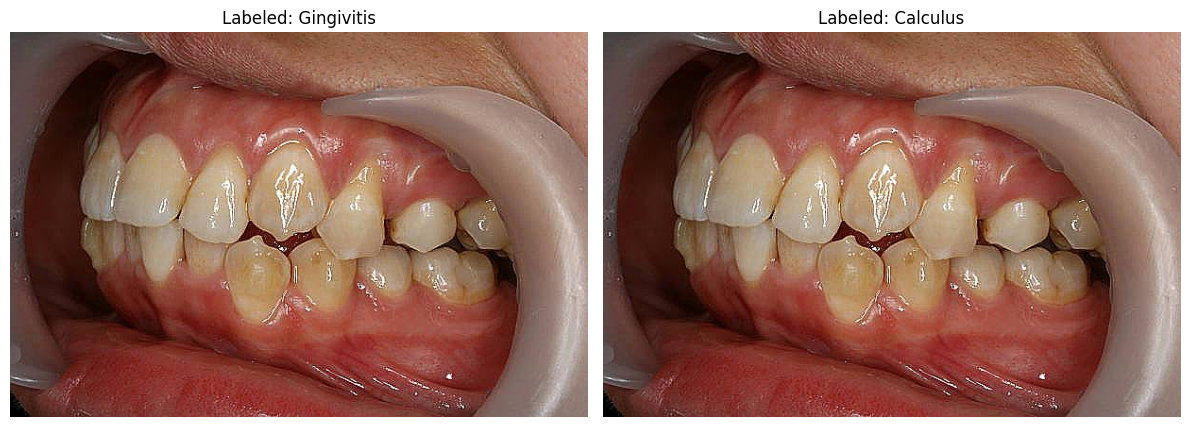

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

gingivitis_path = r"D:\AI_Diploma\Training tasks\Sprint_2\dataset\Gingivitis\Gingivitis\(2179).jpg"
calculus_path = r"D:\AI_Diploma\Training tasks\Sprint_2\dataset\Calculus\Calculus\(1259).jpg"

gingivitis_image = Image.open(gingivitis_path).convert("RGB")
calculus_image = Image.open(calculus_path).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(gingivitis_image)
axes[0].set_title("Labeled: Gingivitis")
axes[0].axis("off")

axes[1].imshow(calculus_image)
axes[1].set_title("Labeled: Calculus")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [23]:
# Hashes that appear in more than one class
cross_class_hashes = set(cross_class_duplicates.index)

# All files belonging to those conflicting groups
cross_class_conflict_images = hash_df[
    hash_df["hash"].isin(cross_class_hashes)
].copy()

print(
    "Images involved in cross-class conflicts:",
    len(cross_class_conflict_images)
)

print(
    "Number of conflicting duplicate groups:",
    len(cross_class_hashes)
)

Images involved in cross-class conflicts: 1510
Number of conflicting duplicate groups: 392


In [24]:
conflict_summary = (
    cross_class_conflict_images
    .groupby("hash")
    .agg(
        number_of_files=("path", "count"),
        number_of_classes=("class", "nunique"),
        classes=("class", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
)

print(conflict_summary["number_of_classes"].value_counts().sort_index())

number_of_classes
2    377
3     14
4      1
Name: count, dtype: int64


In [25]:
# Hashes that are duplicated but NOT cross-class conflicts
all_duplicate_hashes = set(
    hash_df[
        hash_df["hash"].duplicated(keep=False)
    ]["hash"]
)

same_class_hashes = (
    all_duplicate_hashes - cross_class_hashes
)

same_class_duplicates = hash_df[
    hash_df["hash"].isin(same_class_hashes)
].copy()

print(
    "Same-class duplicate groups:",
    len(same_class_hashes)
)

print(
    "Files involved in same-class duplicates:",
    len(same_class_duplicates)
)

Same-class duplicate groups: 383
Files involved in same-class duplicates: 929


In [26]:
# Number of files that are part of cross-class conflicts
cross_class_files = len(cross_class_conflict_images)

# Number of files in same-class duplicate groups
same_class_files = len(same_class_duplicates)

# Number of same-class duplicate groups
same_class_groups = len(same_class_hashes)

# For same-class duplicates, keep one file per group
same_class_files_to_remove = same_class_files - same_class_groups

# Calculate final expected dataset size
original_count = len(classification_images_df)

expected_clean_count = (
    original_count
    - cross_class_files
    - same_class_files_to_remove
)

print("Original classification images:", original_count)
print("Cross-class conflict files:", cross_class_files)
print("Same-class duplicate files to remove:", same_class_files_to_remove)
print("Expected clean images:", expected_clean_count)

Original classification images: 12320
Cross-class conflict files: 1510
Same-class duplicate files to remove: 546
Expected clean images: 10264


In [31]:
# ============================================
# CLEAN DATASET — CLASS LABEL & DISTRIBUTION
# ============================================

# 1. Define the correct class mapping
class_mapping = {
    "Calculus": "Calculus",
    "Data caries": "Caries",
    "Gingivitis": "Gingivitis",
    "Mouth Ulcer": "Mouth Ulcer",
    "Tooth Discoloration": "Tooth Discoloration",
    "hypodontia": "Hypodontia"
}

# 2. Add the clean class label
clean_dataset_df["class"] = (
    clean_dataset_df["top_level_folder"]
    .map(class_mapping)
)

# 3. Check for images without a valid class
missing_classes = clean_dataset_df["class"].isna().sum()

print("Images without class:", missing_classes)

# 4. Display class distribution
clean_class_counts = (
    clean_dataset_df["class"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\nClean dataset class distribution:")
print(clean_class_counts)

# 5. Calculate percentages
clean_class_percentages = (
    clean_class_counts / len(clean_dataset_df) * 100
).round(2)

print("\nClass percentages:")
print(clean_class_percentages)

# 6. Final dataset size
print("\nTotal clean images:", len(clean_dataset_df))

Images without class: 0

Clean dataset class distribution:
class
Mouth Ulcer            2784
Caries                 2573
Tooth Discoloration    2007
Gingivitis             1236
Hypodontia             1215
Calculus                449
Name: count, dtype: int64

Class percentages:
class
Mouth Ulcer            27.12
Caries                 25.07
Tooth Discoloration    19.55
Gingivitis             12.04
Hypodontia             11.84
Calculus                4.37
Name: count, dtype: float64

Total clean images: 10264


In [32]:
from sklearn.model_selection import train_test_split

# ============================================
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================

# First split:
# 70% training
# 30% temporary (validation + test)

train_df, temp_df = train_test_split(
    clean_dataset_df,
    test_size=0.30,
    stratify=clean_dataset_df["class"],
    random_state=42
)

# Second split:
# Split the 30% temporary set equally
# → 15% validation
# → 15% test

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Display sizes
print("Dataset split:")
print("----------------")
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))


Dataset split:
----------------
Training: 7184
Validation: 1540
Test: 1540
Total: 10264


In [33]:
# ============================================
# VERIFY STRATIFIED SPLIT
# ============================================

# Count classes in each split
train_counts = train_df["class"].value_counts()
val_counts = val_df["class"].value_counts()
test_counts = test_df["class"].value_counts()

# Combine into one table
split_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

# Add percentages
split_percentages = split_distribution.div(
    split_distribution.sum(axis=0),
    axis=1
) * 100

split_percentages = split_percentages.round(2)

print("Class distribution (%):")
print(split_percentages)

Class distribution (%):
                     Train  Validation   Test
class                                        
Mouth Ulcer          27.13       27.14  27.08
Caries               25.07       25.06  25.06
Tooth Discoloration  19.56       19.55  19.55
Gingivitis           12.04       12.01  12.08
Hypodontia           11.83       11.82  11.88
Calculus              4.37        4.42   4.35


In [34]:
# ============================================
# SAVE FIXED DATASET SPLITS
# ============================================

# Create a directory for our dataset indexes
split_dir = Path("data_splits")
split_dir.mkdir(exist_ok=True)

# Save the three splits
train_df.to_csv(
    split_dir / "train.csv",
    index=False
)

val_df.to_csv(
    split_dir / "validation.csv",
    index=False
)

test_df.to_csv(
    split_dir / "test.csv",
    index=False
)

print("Dataset splits saved successfully.")
print()
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Dataset splits saved successfully.

Training: 7184
Validation: 1540
Test: 1540
Total: 10264


In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ============================================
# CALCULATE CLASS WEIGHTS
# ============================================

# Get the classes in a fixed, consistent order
classes = sorted(train_df["class"].unique())

# Calculate balanced class weights using TRAINING data only
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(classes),
    y=train_df["class"]
)

# Convert to a dictionary
class_weights = dict(
    zip(classes, class_weights_array)
)

print("Classes:")
print(classes)

print("\nClass weights:")
for class_name, weight in class_weights.items():
    print(f"{class_name:20s}: {weight:.4f}")

Classes:
['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Mouth Ulcer', 'Tooth Discoloration']

Class weights:
Calculus            : 3.8132
Caries              : 0.6648
Gingivitis          : 1.3842
Hypodontia          : 1.4086
Mouth Ulcer         : 0.6143
Tooth Discoloration : 0.8522


In [36]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.9.1+cpu
Torchvision version: 0.24.1+cpu


In [37]:
from torchvision import transforms

# ============================================
# IMAGE PREPROCESSING & AUGMENTATION
# ============================================

IMAGE_SIZE = 224

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# --------------------------------------------
# Training transformations
# --------------------------------------------

train_transform = transforms.Compose([
    
    # Resize all images to our target size
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    # Randomly flip left ↔ right
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Small realistic rotation
    transforms.RandomRotation(degrees=15),
    
    # Small translations and scaling
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),
    
    # Mild lighting variation
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    
    # Convert PIL image → PyTorch tensor
    transforms.ToTensor(),
    
    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# --------------------------------------------
# Validation / Test transformations
# --------------------------------------------

val_test_transform = transforms.Compose([
    
    # No random augmentation here
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    # Convert PIL image → tensor
    transforms.ToTensor(),
    
    # Same normalization as training
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("Image size:", IMAGE_SIZE)
print("\nTraining transformations:")
print(train_transform)

print("\nValidation/Test transformations:")
print(val_test_transform)

Image size: 224

Training transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05), scale=(0.9, 1.1))
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [38]:
# ============================================
# FINAL EDA SUMMARY
# ============================================

print("=" * 50)
print("ORAL DISEASE DATASET - FINAL EDA SUMMARY")
print("=" * 50)

print(f"\nOriginal classification images : {len(classification_images_df)}")
print(f"Cross-class conflict images    : {cross_class_files}")
print(f"Same-class duplicates removed  : {same_class_files_to_remove}")
print(f"Final clean images             : {len(clean_dataset_df)}")

print("\nDataset Split")
print("-" * 30)
print(f"Training                       : {len(train_df)}")
print(f"Validation                     : {len(val_df)}")
print(f"Test                           : {len(test_df)}")

print("\nClass Weights")
print("-" * 30)

for class_name, weight in class_weights.items():
    print(f"{class_name:20s}: {weight:.4f}")

print("\nEDA and data preparation completed successfully.")

ORAL DISEASE DATASET - FINAL EDA SUMMARY

Original classification images : 12320
Cross-class conflict images    : 1510
Same-class duplicates removed  : 546
Final clean images             : 10264

Dataset Split
------------------------------
Training                       : 7184
Validation                     : 1540
Test                           : 1540

Class Weights
------------------------------
Calculus            : 3.8132
Caries              : 0.6648
Gingivitis          : 1.3842
Hypodontia          : 1.4086
Mouth Ulcer         : 0.6143
Tooth Discoloration : 0.8522

EDA and data preparation completed successfully.
